### Code to produce the standard plots

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt

##### cvh Plot

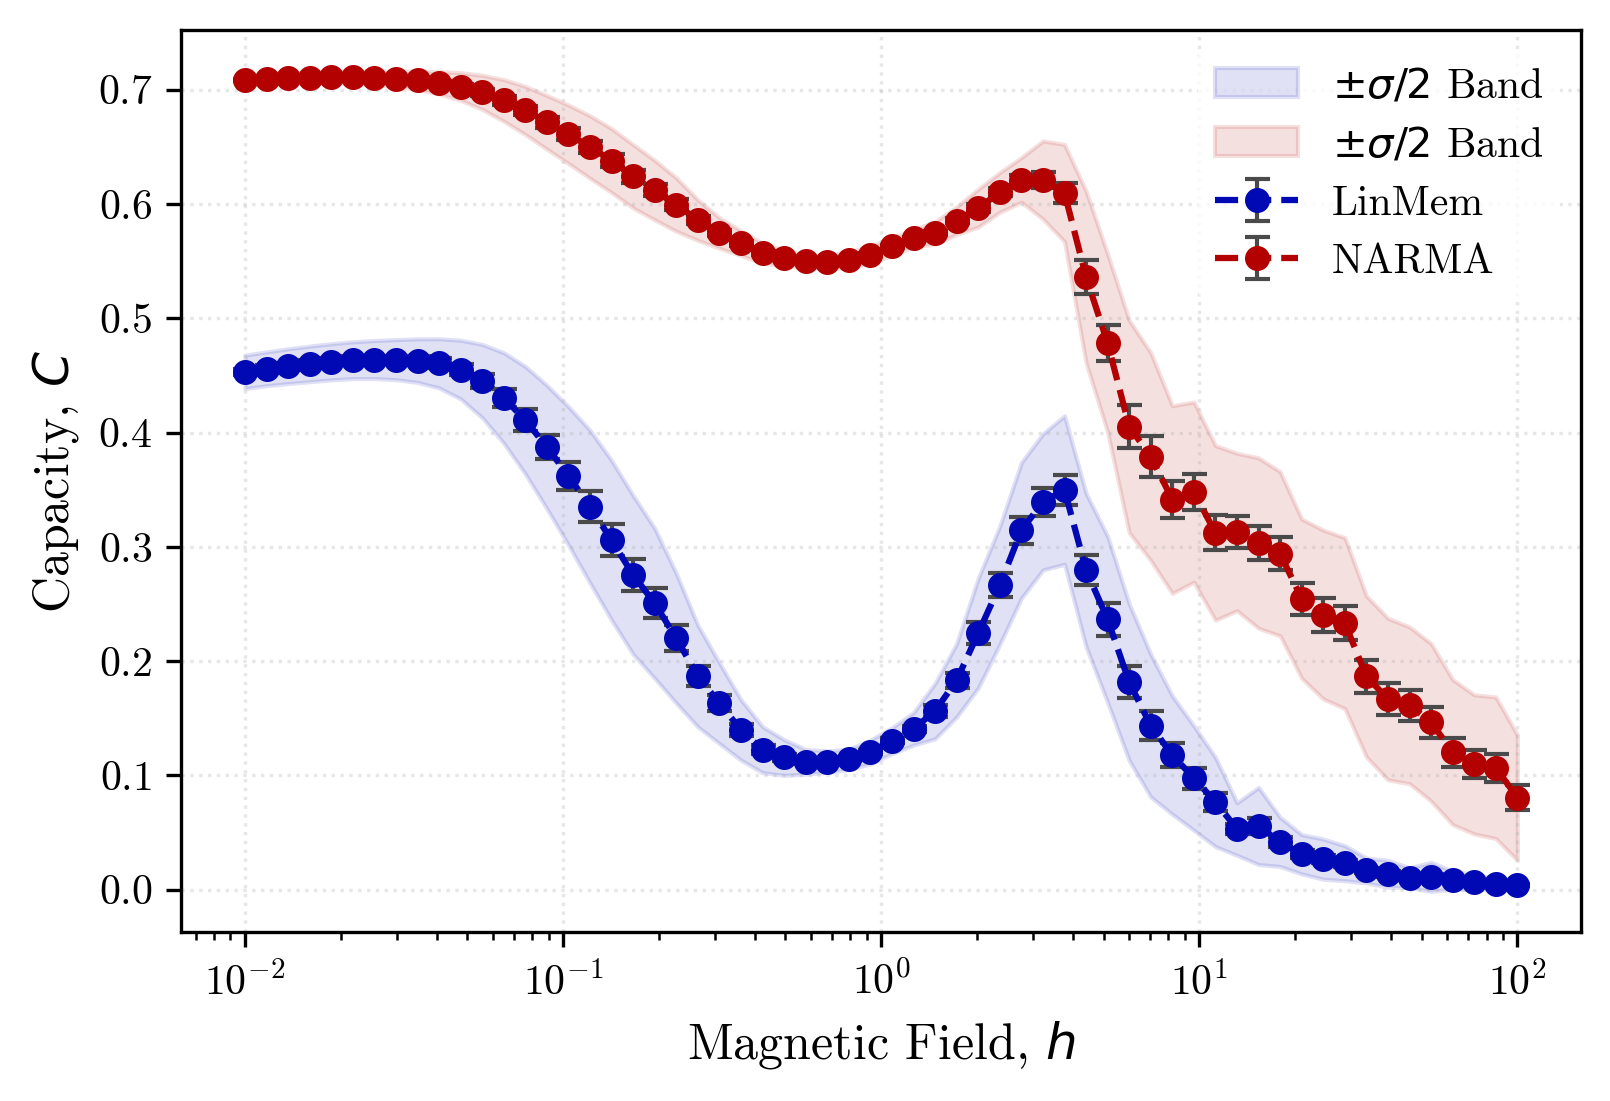

In [2]:
# -----------------------------------------------------------------------------
# 1. LaTeX-Style Plot Configurations
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "text.usetex": False,            # Keeps it independent of a local LaTeX engine
    "font.family": "serif",          
    # We use Matplotlib's built-in Computer Modern (cmr10) and standard fallbacks
    "font.serif": ["cmr10", "DejaVu Serif", "Liberation Serif", "Bitstream Vera Serif"], 
    "font.size": 11,                 
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,               
    "grid.alpha": 0.3,
    "grid.linestyle": ":",
    "axes.formatter.use_mathtext": True
})

# -----------------------------------------------------------------------------
# 2. Load and Prepare Data (Mocked here for the script structure)
# -----------------------------------------------------------------------------
Data = np.load('Data/Cvh/Heisenberg_1DNN_Cvh.npz')
C_raw_LinMem = Data['c_raw_LinMem']
C_mean_LinMem = Data['c_mean_LinMem']
C_se_LinMem = Data['c_se_LinMem']
C_std_LinMem = Data['c_std_LinMem']
C_raw_NARMA = Data['c_raw_NARMA']
C_mean_NARMA = Data['c_mean_NARMA']
C_se_NARMA = Data['c_se_NARMA']
C_std_NARMA = Data['c_std_NARMA']
h_values = Data['h_values']

# (Placeholder data for testing execution)
#h_values = np.logspace(-2, 2, 20)
#C_mean = 1 / (1 + h_values)
#C_se = 0.02 * np.ones_like(h_values)
#C_std = 0.1 * np.ones_like(h_values)

over_line_LinMem = C_mean_LinMem + C_std_LinMem / 2
under_line_LinMem = C_mean_LinMem - C_std_LinMem / 2
over_line_NARMA = C_mean_NARMA + C_std_NARMA / 2
under_line_NARMA = C_mean_NARMA - C_std_NARMA / 2

# -----------------------------------------------------------------------------
# 3. Plotting (Targeted for a standard single-column width ~ 5-6 inches)
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 3.8),dpi=300)

# Define an academic color palette (e.g., Deep Burgundy/Crimson instead of bright red)
primary_color_NARMA = '#b30000' 
primary_color_LinMem = "#0009b3"

# Cleaned up: Using errorbar natively as the main line/marker plotter
ax.errorbar(
    h_values, C_mean_LinMem, yerr=C_se_LinMem, 
    fmt='--o', color=primary_color_LinMem, markersize=5, linewidth=1.5,
    capsize=3, elinewidth=1, ecolor="#4a4a4a", # Subtle gray for error bars
    label='LinMem'
)
ax.errorbar(
    h_values, C_mean_NARMA, yerr=C_se_NARMA, 
    fmt='--o', color=primary_color_NARMA, markersize=5, linewidth=1.5,
    capsize=3, elinewidth=1, ecolor='#4a4a4a', # Subtle gray for error bars
    label='NARMA'
)

# Standard deviation band
ax.fill_between(
    h_values, under_line_LinMem, over_line_LinMem, 
    color=primary_color_LinMem, alpha=0.12, label=r'$\pm \sigma/2$ Band'
)
ax.fill_between(
    h_values, under_line_NARMA, over_line_NARMA, 
    color=primary_color_NARMA, alpha=0.12, label=r'$\pm \sigma/2$ Band'
)

# Set logarithmic scale explicitly on the axis object
ax.set_xscale('log')

# Formatting labels with proper mathematical LaTeX syntax
ax.set_xlabel(r'Magnetic Field, $h$')
ax.set_ylabel(r'Capacity, $C$')

ax.legend(frameon=True, facecolor='white', edgecolor='none')

# Clean up layout padding
plt.tight_layout()

# -----------------------------------------------------------------------------
# 4. Saving for LaTeX
# -----------------------------------------------------------------------------
# Vector formats (PDF/EPS) keep lines and text infinitely sharp in your paper.
#plt.savefig('Plots/heisenberg_narma_cvh.pdf', bbox_inches='tight', dpi=300)
plt.show()

#### prediction and target plots

In [3]:
# load data
data_I = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_III.npz')
data_II = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_III-IV.npz')
data_III = np.load('Data/Prediction/Fully_connected_TFIM_LinMem_NARMA_IV.npz')

In [4]:
# get the predictions and targets for three different parameter values
y_pred_linmem_I = data_I['pred_linmem']
y_target_linmem_I = data_I['target_linmem']
y_pred_narma_I = data_I['pred_narma']
y_target_narma_I = data_I['target_narma']

y_pred_linmem_II = data_II['pred_linmem']
y_target_linmem_II = data_II['target_linmem']
y_pred_narma_II = data_II['pred_narma']
y_target_narma_II = data_II['target_narma']

y_pred_linmem_III = data_III['pred_linmem']
y_target_linmem_III = data_III['target_linmem']
y_pred_narma_III = data_III['pred_narma']
y_target_narma_III = data_III['target_narma']

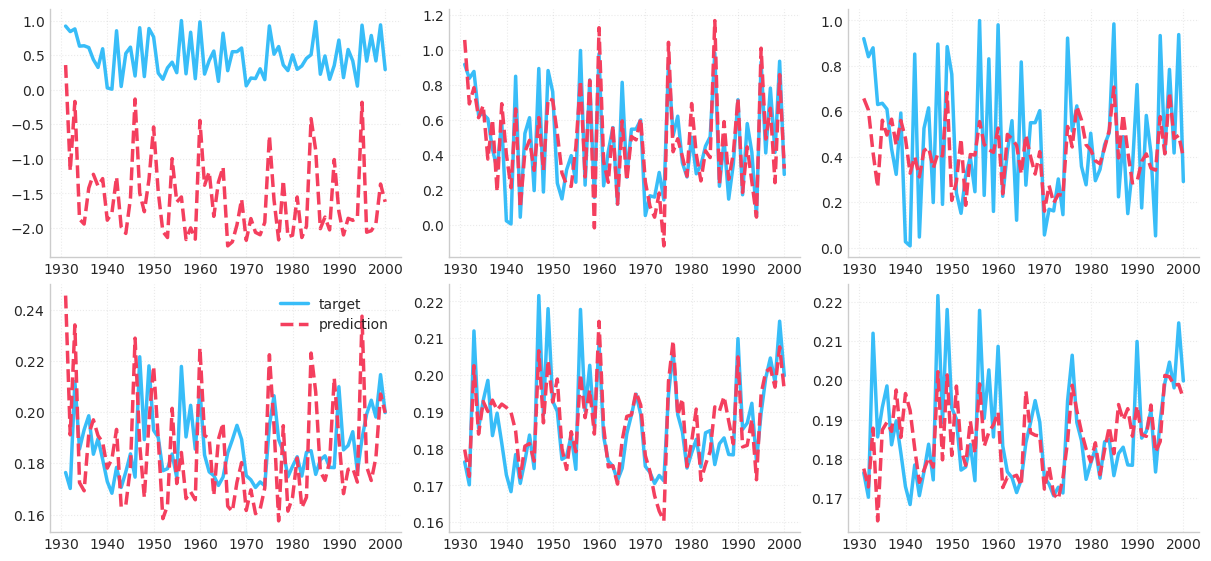

In [5]:
# Set dark theme for presentation slides (switch to 'seaborn-v0_8-whitegrid' for light slides)('dark_background' for dark slides)
plt.style.use('seaborn-v0_8-whitegrid')

# Set global font sizes suited for a presentation slide
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif'
})

# Create dummy data
time_steps = np.linspace(0, 2000, 2000)

# 2 rows, 3 columns fits 16:9 widescreen slides significantly better
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5.5), layout='constrained')

# --- Subplot (0, 0): Line Plot ---
axes[0, 0].plot(time_steps[-70:], y_target_linmem_I[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 0].plot(time_steps[-70:], y_pred_linmem_I[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')
#axes[0, 0].set_title('region III')
#axes[0, 0].legend(loc='upper right', frameon=False)

# --- Subplot (0, 1): Bar Chart ---
axes[1, 0].plot(time_steps[-70:], y_target_narma_I[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 0].plot(time_steps[-70:], y_pred_narma_I[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')
#axes[1, 0].set_title('region III')
axes[1, 0].legend(loc='upper right', frameon=False)

# --- Subplot (1, 0): Scatter Plot ---
axes[0, 1].plot(time_steps[-70:], y_target_linmem_II[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 1].plot(time_steps[-70:], y_pred_linmem_II[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (1, 1): Histogram ---
axes[1, 1].plot(time_steps[-70:], y_target_narma_II[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 1].plot(time_steps[-70:], y_pred_narma_II[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (2, 0): Exponential Decay ---
axes[0, 2].plot(time_steps[-70:], y_target_linmem_III[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[0, 2].plot(time_steps[-70:], y_pred_linmem_III[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')

# --- Subplot (2, 1): Damped Oscillation ---
axes[1, 2].plot(time_steps[-70:], y_target_narma_III[-70:], color='#38bdf8', lw=2.5, label=r'target')
axes[1, 2].plot(time_steps[-70:], y_pred_narma_III[-70:], color='#f43f5e', lw=2.5, linestyle='--', label=r'prediction')


# Clean grid lines across all subplots
for ax in axes.flat:
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Save high-resolution PNG transparently or as a vector PDF for LaTeX Beamer
#plt.savefig('Plots/Heisenberg_1DNN_Ji_y_pred_plot.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('Plots/Fully_connected_TFIM_y_pred_plot.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()